In [1]:
# Setup and Data
import yfinance as yf 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from statsmodels.tsa.stattools import adfuller, acf
import warnings 
import scipy.stats as stats
from hurst import compute_Hc 
import matplotlib.patches as mpatches 
import matplotlib.lines as mlines 

warnings.filterwarnings('ignore')

In [2]:
 
def get_series_from_yf(ticker: str):
    d = yf.download(ticker)['Close']
    d = d[d > 0]
    d = d.dropna() 
    print(f"Date Range: {d.index.min().date()} to {d.index.max().date()}") 
    return d


wti = get_series_from_yf('CL=F')
gold = get_series_from_yf('GC=F') 

wti_log_returns = np.log(wti).diff().dropna().squeeze() 
gold_log_returns = np.log(gold).diff().dropna().squeeze()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Date Range: 2000-08-23 to 2026-03-13


[*********************100%***********************]  1 of 1 completed

Date Range: 2000-08-30 to 2026-03-13


In [ ]:
from hmmlearn.hmm import GaussianHMM 
data = pd.DataFrame({
    "log_returns": wti_log_returns 
}) 
data["rolling_std"] = data["log_returns"].rolling(24).std() 
data = data.dropna()
model = GaussianHMM(
    n_components=2, # number of regimes. regime 0 is normal, regime 1 is crisis
    covariance_type="full",
    n_iter=100, 
    random_state=42 
) 
model.fit(data) 
hidden_states = model.predict(data)

print("Learned means:\n", model.means_)
print("\nLearned stds:\n", np.sqrt(model.covars_.reshape(2, -1)[:, [0, 2]]))
print("\nTransition matrix:\n", model.transmat_)

Learned means:
 [[ 0.00029255  0.01876963]
 [-0.00045424  0.04447454]]

Learned stds:
 [[0.0192874  0.00174765]
 [0.0521752  0.00924634]]

Transition matrix:
 [[0.99522187 0.00477813]
 [0.02659753 0.97340247]]


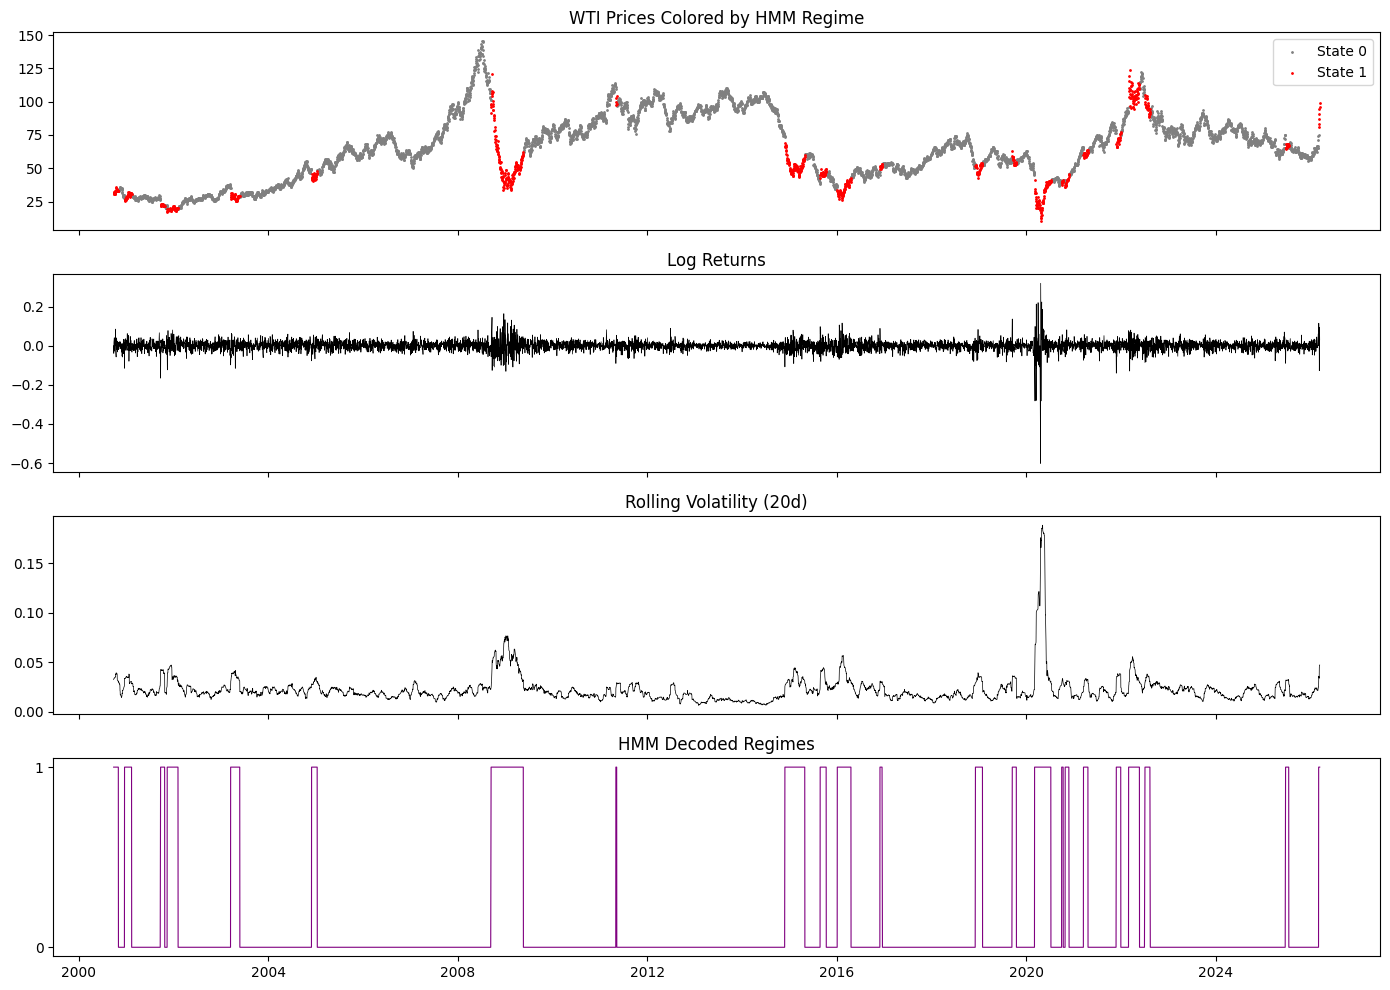

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

colors = ['gray', 'red']

# Price series colored by regime
for i in range(len(colors) ):
    mask = hidden_states == i
    axes[0].scatter(data.index[mask], wti.loc[data.index[mask]], 
                    c=colors[i], s=1, label=f"State {i}")
axes[0].set_title("WTI Prices Colored by HMM Regime")
axes[0].legend()

# Returns
axes[1].plot(data.index, data["log_returns"], color='black', linewidth=0.5)
axes[1].set_title("Log Returns")

# Rolling volatility
axes[2].plot(data.index, data["rolling_std"], color='black', linewidth=0.5)
axes[2].set_title("Rolling Volatility (20d)")

# Regime states
axes[3].plot(data.index, hidden_states, color='purple', linewidth=0.8)
axes[3].set_title("HMM Decoded Regimes")
axes[3].set_yticks([0, 1])

plt.tight_layout()
plt.show()

3-State Model Findings:
The model found three regimes — bullish (positive mean, moderate vol), bearish (negative mean, moderate vol), and crisis (near-zero mean, extreme vol at ~4.6%). The crisis state is extremely persistent (0.97 diagonal, ~33 day average duration). However, the model defines crisis by volatility, not direction — it lumps supply-shock rallies (Russia-Ukraine 2022, Iran-US 2026) and demand crashes (shale glut, COVID) into the same state because both have similar volatility profiles. States 0 and 1 (bullish/bearish) swap frequently and are hard for the model to cleanly separate since their vol is similar.
2-State Model Rationale:
Since the model's primary structural finding is a binary split between "normal" and "crisis" (defined by volatility), a 2-state model is cleaner. The HMM answers one question: are we in crisis or not? The direction of the crisis — bullish supply shock vs. bearish demand collapse — is better determined by macro overlay (OPEC decisions, inventory data, geopolitical context, term structure) rather than asking the HMM to separate regimes it can't distinguish statistically.
Implication for the pipeline:
HMM (2-state) handles regime detection → macro overlay determines crisis character → strategy selection follows from the combination. This is also the cleaner narrative for the LinkedIn series.